In [15]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

Text(0, 0.5, 'qwerty dimension 2')

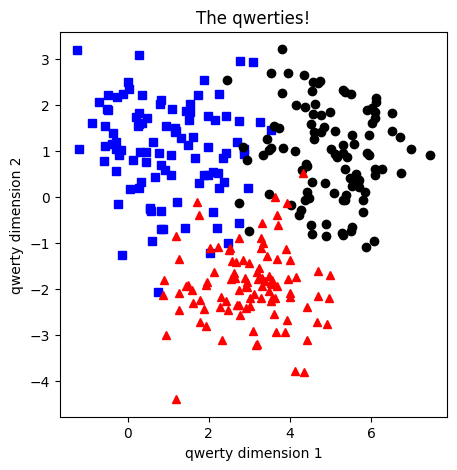

In [16]:
nPerClust = 100
blur = 1

A = [1,1]
B = [5,1]
C = [3,-2]

a = [A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur]
c = [C[0]+np.random.randn(nPerClust)*blur, C[1]+np.random.randn(nPerClust)*blur]

labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1)),1+np.ones((nPerClust,1))))

data_np = np.hstack((a,b,c)).T

data = torch.tensor(data_np).float()
labels = torch.squeeze(torch.tensor(labels_np).long())

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')

In [17]:
ANNq = nn.Sequential(
    nn.Linear(2,4),
    nn.ReLU(),
    nn.Linear(4,3),
    nn.Softmax(dim=1),
)

lossfun = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(ANNq.parameters(),lr=.01)

In [18]:
yHat = ANNq(data)

print(data.shape)
print(yHat.shape)

torch.Size([300, 2])
torch.Size([300, 3])


In [19]:
numepochs = 20000

losses = torch.zeros(numepochs)
ongoingAcc = []

for epochi in range(numepochs):

    yHat = ANNq(data)

    loss = lossfun(yHat, labels)
    losses[epochi] = loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    matches = torch.argmax(yHat,axis=1) == labels
    matchesNumeric = matches.float()
    accyracyPct = 100*torch.mean(matchesNumeric)
    ongoingAcc.append(accyracyPct)

predictions = ANNq(data)

predlabels = torch.argmax(predictions, axis=1)
totalacc = 100*torch.mean((predlabels == labels).float())

Final accuracy:  tensor(94.)


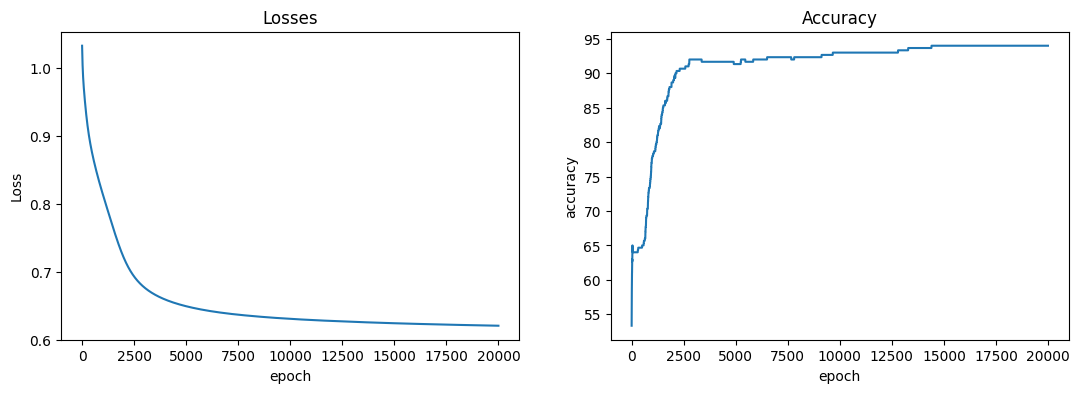

In [20]:
print('Final accuracy: ', totalacc)

fig, ax = plt.subplots(1,2,figsize=(13,4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_title('Losses')

ax[1].plot(ongoingAcc)
ax[1].set_ylabel('accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_title('Accuracy')

plt.show()